# Ropedia Academy — C7 · Gaze & attention modeling

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/C7.ipynb)

> **Visualizes gaze as a Gaussian attention heatmap with the fixation point, plus a timeline showing gaze leads the hand (the anticipation cue).**
>
> 把注视可视化为带注视点的高斯注意力热图，并用时间线展示注视领先于手（预判线索）。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/C7

gaze-attended feature: (64,) | gaze leads hand by 4 frames


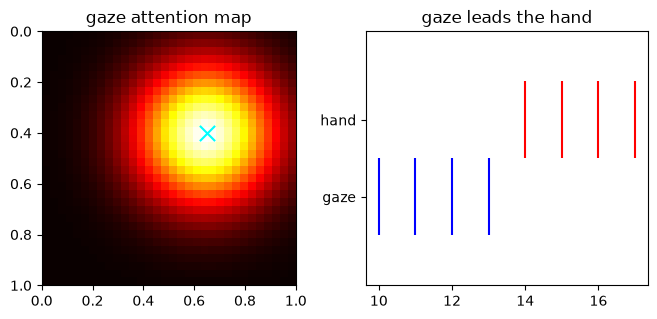

In [1]:
import torch, matplotlib.pyplot as plt
# Gaze: a Gaussian attention map; gaze leads the hand (an anticipation cue).

# ---------- INPUT: a fixation point + a feature map ----------
H = W = 32
gaze = torch.tensor([0.65, 0.4])
feat = torch.randn(64, H, W)

# ---------- MODEL: build the gaze attention map + pool the feature ----------
ys, xs = torch.linspace(0,1,H)[:,None], torch.linspace(0,1,W)[None,:]
g = torch.exp(-(((xs-gaze[0])**2 + (ys-gaze[1])**2) / (2*0.04))); g = g / g.sum()
pooled = (feat * g).sum((1, 2))
gaze_t = torch.arange(10, 14); hand_t = gaze_t + 4        # eye lands before the reach

# ---------- OUTPUT: pooled shape + the attention map and the lead-time timeline ----------
print("gaze-attended feature:", tuple(pooled.shape),
      "| gaze leads hand by", int((hand_t - gaze_t).float().mean()), "frames")
fig, ax = plt.subplots(1, 2, figsize=(8, 3.3))
ax[0].imshow(g, cmap='hot', extent=[0,1,1,0]); ax[0].scatter(*gaze, c='cyan', marker='x', s=120)
ax[0].set_title("gaze attention map")
ax[1].eventplot([gaze_t.tolist(), hand_t.tolist()], colors=['b','r'])
ax[1].set_yticks([0,1]); ax[1].set_yticklabels(['gaze','hand']); ax[1].set_title("gaze leads the hand")
plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/C7
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks